<a href="https://colab.research.google.com/github/Poojashrees3/Statistics-and-machine-learning/blob/Mybranch/Exercises_Day_13_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Loading and Exploration**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


air_data = pd.read_csv('/content/AirPassengers.csv')
air_data['Month'] = pd.to_datetime(air_data['Month'])
air_data.set_index('Month', inplace=True)

air_data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [3]:
# Checking for missing values
missing = air_data.isnull().sum()
print(missing)


#Passengers    0
dtype: int64


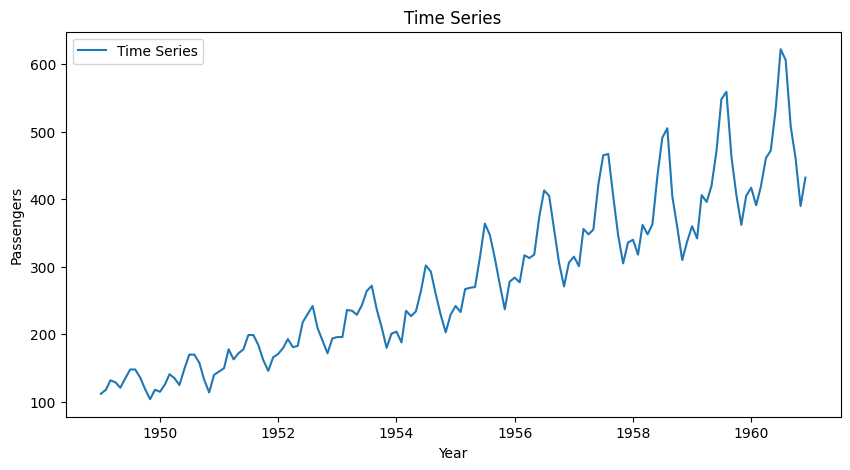

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(air_data.index, air_data['#Passengers'], label='Time Series')
plt.title('Time Series')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()

Trend: Upward trend in air travel

Seasonality: Peaks in travel during certain months of the year.

Irregular Patterns: Random fluctuations likely due to external factors

**Time Series Decomposition**

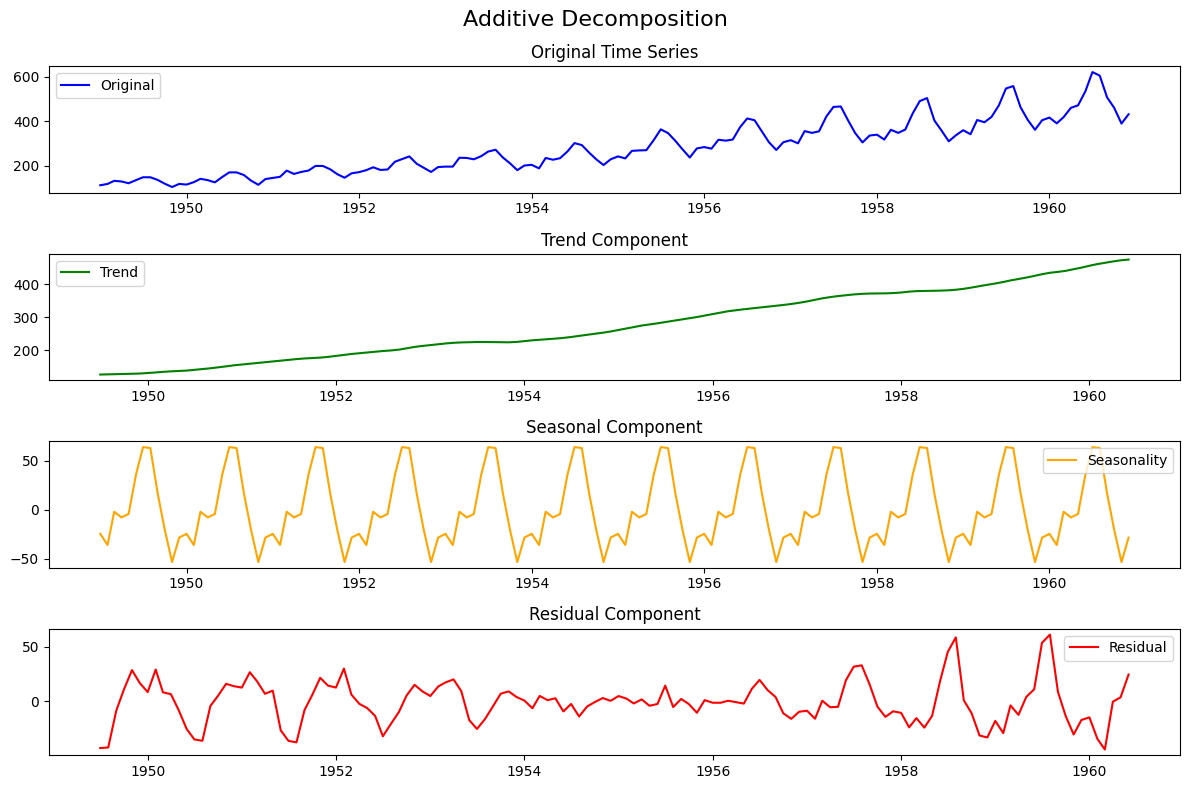

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive Decomposition
additive_decomposition = seasonal_decompose(air_data['#Passengers'], model='additive', period=12)

# Plot Additive Decomposition
plt.figure(figsize=(12, 8))
plt.suptitle('Additive Decomposition', fontsize=16)

plt.subplot(4, 1, 1)
plt.plot(air_data.index,air_data['#Passengers'], label='Original', color='blue')
plt.title('Original Time Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(air_data.index,additive_decomposition.trend, label='Trend', color='green')
plt.title('Trend Component')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(air_data.index,additive_decomposition.seasonal, label='Seasonality', color='orange')
plt.title('Seasonal Component')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(air_data.index,additive_decomposition.resid, label='Residual', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

**Original Series**: Displays the overall pattern of the data, which includes both the trend and seasonality.

**Trend**:A clear upward slope indicates a strong trend , indicating that air travel was becoming more popular.

**Seasonality** : appears to be fairly consistent over time, with a similar pattern repeating each year.The peaks likely correspond  seasonal patterns, indicating higher passenger numbers in certain months of the year.

**Residual** : appear to be relatively random, with no clear patterns or trends,represents irregular patterns or noise that cannot be explained by the trend or seasonality.

**Trend Estimation**

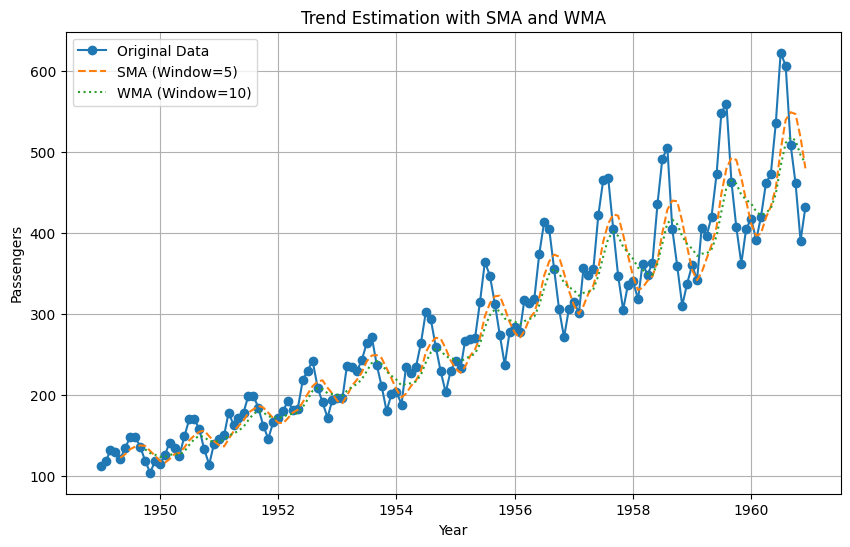

In [ ]:
import numpy as np

# Simple Moving Average (SMA) function
def calculate_sma(data, window):
    return data.rolling(window=window).mean()

# Weighted Moving Average (WMA) function
def calculate_wma(data, window):
    weights = np.arange(1, window + 1)
    return data.rolling(window=window).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

# Parameters
window_size_sma = 5 # Adjust the window size as needed
window_size_wma = 10 # Adjust the window size as needed

# Calculate SMA and WMA
sma = calculate_sma(air_data['#Passengers'], window_size_sma)
wma = calculate_wma(air_data['#Passengers'], window_size_wma)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(air_data.index,air_data['#Passengers'], label="Original Data", marker="o")
plt.plot(sma, label=f"SMA (Window={window_size_sma})", linestyle="--")
plt.plot(wma, label=f"WMA (Window={window_size_wma})", linestyle=":")
plt.title("Trend Estimation with SMA and WMA")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()

**Exponential Smoothing**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
<ipython-input-16-244e12230e54>:12: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fitted_model = model.fit(smoothing_level=smoothing_level, smoothing_slope=smoothing_slope, optimized=False)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


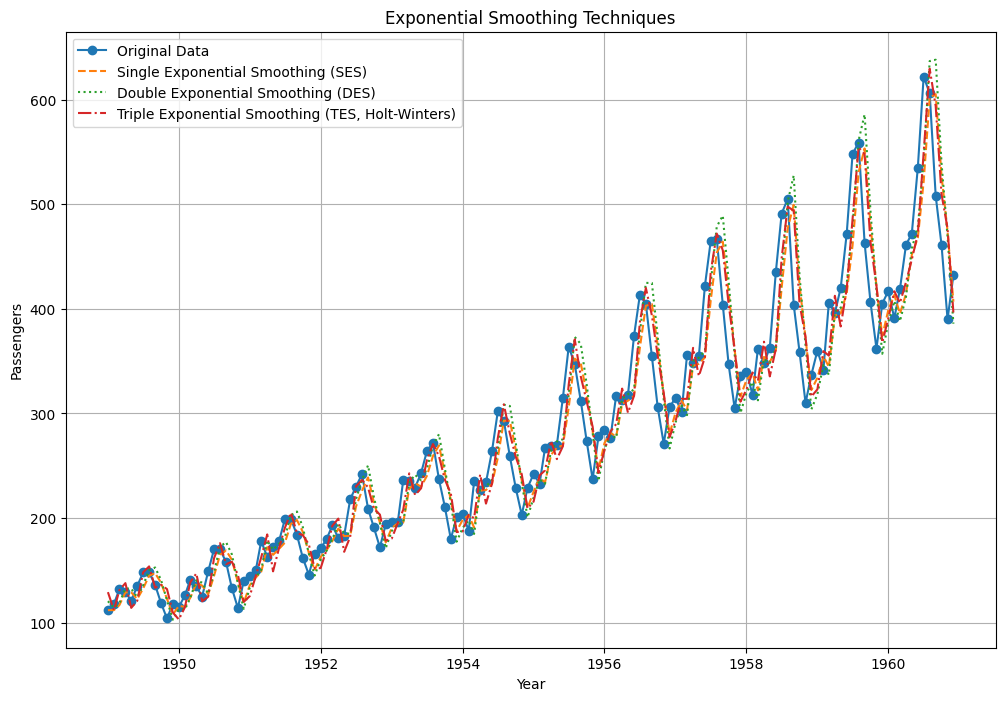

SES Forecast: 1961-01-01    426.971494
1961-02-01    426.971494
1961-03-01    426.971494
Freq: MS, dtype: float64
DES Forecast: 1961-01-01    410.106229
1961-02-01    397.450814
1961-03-01    384.795399
Freq: MS, dtype: float64
TES Forecast: 1961-01-01    416.846564
1961-02-01    417.092102
1961-03-01    431.421947
Freq: MS, dtype: float64


In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# 1. Single Exponential Smoothing (SES)
def single_exponential_smoothing(data, smoothing_level=0.8):
    model = SimpleExpSmoothing(data)
    fitted_model = model.fit(smoothing_level=smoothing_level, optimized=False)
    return fitted_model.fittedvalues, fitted_model.forecast(steps=3)

# 2. Double Exponential Smoothing (DES)
def double_exponential_smoothing(data, trend="add", smoothing_level=0.8, smoothing_slope=0.2):
    model = ExponentialSmoothing(data, trend=trend, seasonal=None)
    fitted_model = model.fit(smoothing_level=smoothing_level, smoothing_slope=smoothing_slope, optimized=False)
    return fitted_model.fittedvalues, fitted_model.forecast(steps=3)

# 3. Triple Exponential Smoothing (Holt-Winters, TES)
def triple_exponential_smoothing(data, trend="add", seasonal="add", seasonal_periods=4):
    model = ExponentialSmoothing(data, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    fitted_model = model.fit(optimized=True)
    return fitted_model.fittedvalues, fitted_model.forecast(steps=3)

# Apply smoothing methods
smoothing_level = 0.8
smoothing_slope = 0.2
seasonal_periods = 4

ses_fitted, ses_forecast = single_exponential_smoothing(air_data['#Passengers'], smoothing_level)
des_fitted, des_forecast = double_exponential_smoothing(air_data['#Passengers'], "add", smoothing_level, smoothing_slope)
tes_fitted, tes_forecast = triple_exponential_smoothing(air_data['#Passengers'], "add", "add", seasonal_periods=seasonal_periods)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(air_data.index,air_data['#Passengers'], label="Original Data", marker="o")
plt.plot(ses_fitted, label="Single Exponential Smoothing (SES)", linestyle="--")
plt.plot(des_fitted, label="Double Exponential Smoothing (DES)", linestyle=":")
plt.plot(tes_fitted, label="Triple Exponential Smoothing (TES, Holt-Winters)", linestyle="-.")
plt.title("Exponential Smoothing Techniques")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()

# Forecast Output
print("SES Forecast:", ses_forecast)
print("DES Forecast:", des_forecast)
print("TES Forecast:", tes_forecast)

**Forecasting with  AR**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
<ipython-input-52-f896e28764e2>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(air_data.index[-1], periods=12, freq='M'), ar_predictions, label='AR Predictions', color='green')


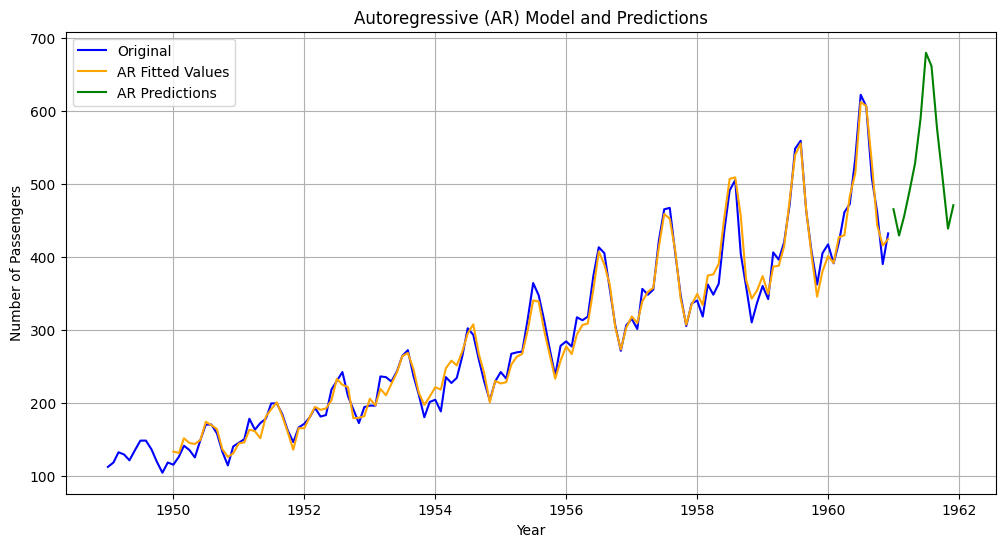

AR Model MAE: 10.468310473879813
AR Model RMSE: 13.510646174724856


In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error

#deleting missing values
air_data.dropna(inplace=True)

# Fit the AR model
ar_model = AutoReg(air_data['#Passengers'], lags=12)  # Using a lag of 12 (yearly seasonality)
ar_fit = ar_model.fit()

# Generate predictions
air_data['AR_Fitted'] = ar_fit.fittedvalues
ar_predictions = ar_fit.predict(start=len(air_data), end=len(air_data) + 11)  # predictions next 12 months

# Plot the original data, AR fitted values, and forecast
plt.figure(figsize=(12, 6))
plt.plot(air_data.index,air_data['#Passengers'], label='Original', color='blue')
plt.plot(air_data.index, air_data['AR_Fitted'], label='AR Fitted Values', color='orange')
plt.plot(pd.date_range(air_data.index[-1], periods=12, freq='M'), ar_predictions, label='AR Predictions', color='green')
plt.title('Autoregressive (AR) Model and Predictions')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# evaluation metrics for the AR model
mae_ar = mean_absolute_error(air_data['#Passengers'][12:], air_data['AR_Fitted'][12:])  # Ignore the first 12 values
rmse_ar = np.sqrt(mean_squared_error(air_data['#Passengers'][12:], air_data['AR_Fitted'][12:]))

print(f"AR Model MAE: {mae_ar}")
print(f"AR Model RMSE: {rmse_ar}")



**Forecasting with  ARIMA**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-51-e5a2da080fa1>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(air_data.

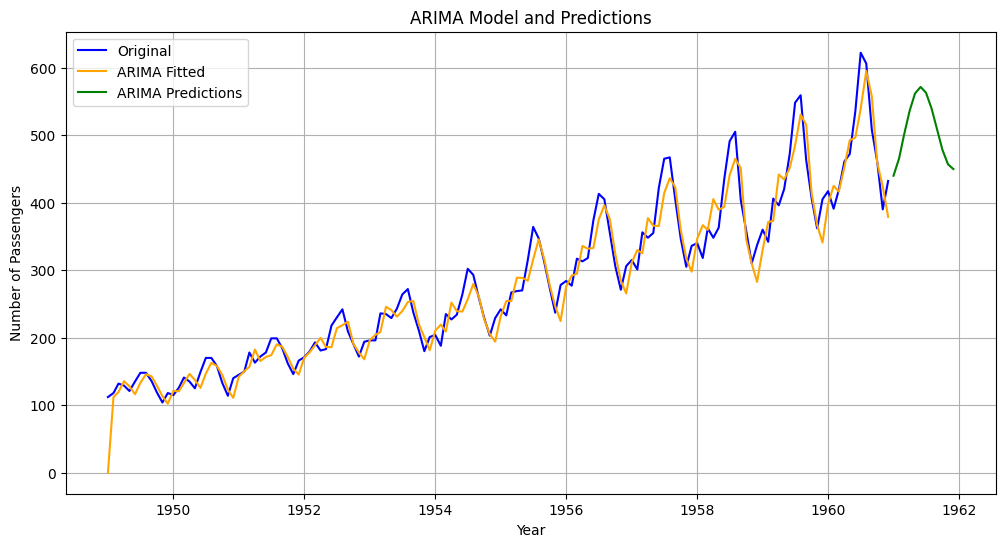

MAE: 20.847338219107254
RMSE: 27.643061199069177


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

#deleting missing values
air_data.dropna(inplace=True)

# Fit ARIMA model
arima_model = ARIMA(air_data['#Passengers'], order=(2, 1, 2))
arima_fit = arima_model.fit()

# Predictions using ARIMA
arima_predictions = arima_fit.forecast(steps=12)

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(air_data.index,air_data['#Passengers'], label='Original', color='blue')
plt.plot(arima_fit.fittedvalues, label='ARIMA Fitted', color='orange')
plt.plot(pd.date_range(air_data.index[-1], periods=12, freq='M'), arima_predictions, label='ARIMA Predictions', color='green')
plt.title('ARIMA Model and Predictions')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# evaluating model
mae = mean_absolute_error(air_data['#Passengers'], arima_fit.fittedvalues)
rmse = np.sqrt(mean_squared_error(air_data['#Passengers'], arima_fit.fittedvalues))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

By comparing models with respect to calculated metrics, AR is best performing method


*   The AR model has a significantly lower RMSE  compared to the ARIMA model. This indicates that, on average, the AR model's predictions are closer to the actual values, resulting in smaller prediction errors
*   the AR model has a lower MAE compared to the ARIMA model . This means that, on average, the AR model's predictions are off by a smaller margin compared to the ARIMA model.

